In [12]:
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Setting visualization style
sns.set_theme(style="whitegrid")

In [13]:
# Loading the cleaned dataset (from the previous notebook) 
file_path = 'data/Anovator_Final_Cleaned_Dataset.csv'
df = pd.read_csv(file_path)

# Defining the Inital Target (what we want to be able to predict)
target = 'score'

# Defining Leakage Columns (derived from score, must be removed)
leakage_cols = ['bodyAge', 'age_gap']

# Defining Metadata (not for modeling, but used for splitting groups)
group_col = 'name'

# Preparing the Features (X) and Target (y)
# Dropping: 
    # Non-numeric columns and 
    # Columns that would cause target leakage
X_raw = df.drop(columns=[target] + leakage_cols + ['id', 'original_url', 'date_created', 'date_modified'], errors='ignore')
y = df[target]

# Keeping only the numeric columns for X
X_numeric = X_raw.select_dtypes(include=[np.number])

print(f"Dataset loaded: {len(df)} records.")
print(f"Features for modeling: {X_numeric.shape[1]}")
print(f"Target variable: {target}")

# Verification of top features
X_numeric.head()

Dataset loaded: 158 records.
Features for modeling: 92
Target variable: score


,age,aerobicGoal,anaGoal,armDim,armSpan,bloodOxygen,bmi,bmr,bodyShape,bodyShapeRisk,...,front_shoulder_angle,front_left_leg_angle,front_right_leg_angle,side_hunchback_risk,side_left_leg_angle,side_right_leg_angle,calc_total_fat,calc_total_muscle,fat_error,muscle_error
0,38,224.640,224.640,23.4979,169.316,0.0,18.075975,1248.29,4,2,...,3.012788,174.41129,180.13610,1.0,191.30994,185.44035,9.676550,32.62616,11.131550,10.45624
1,41,480.865,68.695,25.5552,163.257,0.0,22.958715,1249.99,0,3,...,0.000000,180.57727,179.86390,4.0,175.03026,174.96115,18.544620,34.70006,14.381380,2.15384
2,44,504.660,504.660,38.8264,176.823,0.0,29.824630,1941.01,5,2,...,0.000000,182.86240,177.13759,4.0,168.69006,171.02737,16.833397,63.94324,3.074503,18.81684
3,37,482.820,482.820,36.3273,172.527,0.0,27.977335,1857.87,5,2,...,2.726318,188.30275,169.00750,1.0,175.03027,177.01573,11.280844,59.92150,4.574656,11.34800
4,30,363.090,484.120,35.1739,182.032,0.0,24.000723,1862.79,7,2,...,0.000000,179.54648,177.27368,1.0,174.19554,179.54650,8.232662,61.45511,5.021938,12.09711


In [14]:
# Splitting:
    # 80% of unique individuals for training  
    # 20% for testing
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Defining the groups based on the 'name' column
groups = df[group_col]

# Generating indices for the split
train_idx, test_idx = next(gss.split(X_numeric, y, groups=groups))

# Creating the training and testing sets
X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Logging the split results
print("Split Results:")
print(f"Total Unique Names: {groups.nunique()}")
print(f"Names assigned to Training: {df.iloc[train_idx][group_col].nunique()}")
print(f"Names assigned to Testing: {df.iloc[test_idx][group_col].nunique()}")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Split Results:
Total Unique Names: 53
Names assigned to Training: 42
Names assigned to Testing: 11
Training set size: 145 rows
Testing set size: 13 rows


In [15]:
# Identifying columns with missing values in the training set
missing_info = X_train.isnull().sum()
cols_with_nans = missing_info[missing_info > 0].index.tolist()

print(f"Number of columns requiring imputation/modification: {len(cols_with_nans)}")

# Calculating the median from the training set only
train_medians = X_train.median()

# Applying the training medians to both sets
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Final verification
remaining_nans = X_train.isnull().sum().sum() + X_test.isnull().sum().sum()
print(f"Remaining missing values after imputation/modification: {remaining_nans}")

if len(cols_with_nans) > 0:
    print("\nTop imputed columns:")
    print(missing_info.sort_values(ascending=False).head(10))

Number of columns requiring imputation/modification: 35
Remaining missing values after imputation/modification: 0

Top imputed columns:
faceUserId          139
leftVision          136
rightVision         134
bloodMinPressure    132
bloodMaxPressure    132
restingHeartRate    127
customerId          103
vitalCapacity        67
agility              58
balanceAngle         56
dtype: int64


In [16]:
# Initializing the Standard Scaler
scaler = StandardScaler()

# List of columns to scale (all numeric features)
feature_columns = X_train.columns

# Fitting on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to DataFrame to keep column names for analysis later
X_train = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test = pd.DataFrame(X_test_scaled, columns=feature_columns)

print(f"Mean of first feature after scaling: {X_train.iloc[:, 0].mean():.2f}")
print(f"Std deviation of first feature after scaling: {X_train.iloc[:, 0].std():.2f}")

# Showing the first 5 rows of the scaled features
X_train.head()

Mean of first feature after scaling: -0.00
Std deviation of first feature after scaling: 1.00


,age,aerobicGoal,anaGoal,armDim,armSpan,bloodOxygen,bmi,bmr,bodyShape,bodyShapeRisk,...,front_shoulder_angle,front_left_leg_angle,front_right_leg_angle,side_hunchback_risk,side_left_leg_angle,side_right_leg_angle,calc_total_fat,calc_total_muscle,fat_error,muscle_error
0,0.669516,-0.794750,-0.742420,-1.130960,-1.210375,-0.376446,-1.338661,-1.546822,-0.190742,-0.039677,...,1.639885,-2.588188,0.685882,-1.289111,3.039125,1.500650,-0.071012,-1.419025,1.143812,-0.336989
1,0.913436,0.584204,-1.751681,-0.884389,-2.021947,-0.376446,-0.281181,-1.541379,-2.004359,0.782199,...,-0.517021,-0.438354,0.604818,1.861244,-1.236353,-1.325841,1.090303,-1.282184,2.023057,-1.217005
2,1.157355,0.712264,1.069843,0.706185,-0.204852,-0.376446,1.205806,0.670991,0.262662,-0.039677,...,-0.517021,0.358380,-0.207105,1.861244,-2.901459,-2.386875,0.866210,0.647359,-1.036032,0.549195
3,-1.119225,-0.025151,0.183063,-0.728474,0.021046,-0.376446,-0.139773,-1.014844,1.169470,-0.039677,...,-0.517021,0.267781,-0.156886,-0.238992,0.068833,0.033257,0.109643,-0.922963,0.585495,-0.996256
4,-1.363144,0.107779,0.342919,-0.256199,-0.529802,-0.376446,-0.182198,-0.711332,1.169470,-0.039677,...,-0.517021,0.410809,0.567967,0.811126,2.181113,1.434319,0.610917,-0.472900,0.210094,-1.014648


Baseline Model Performance (Test Set):
Mean Absolute Error: 2.42 points
R-squared Score: 0.63


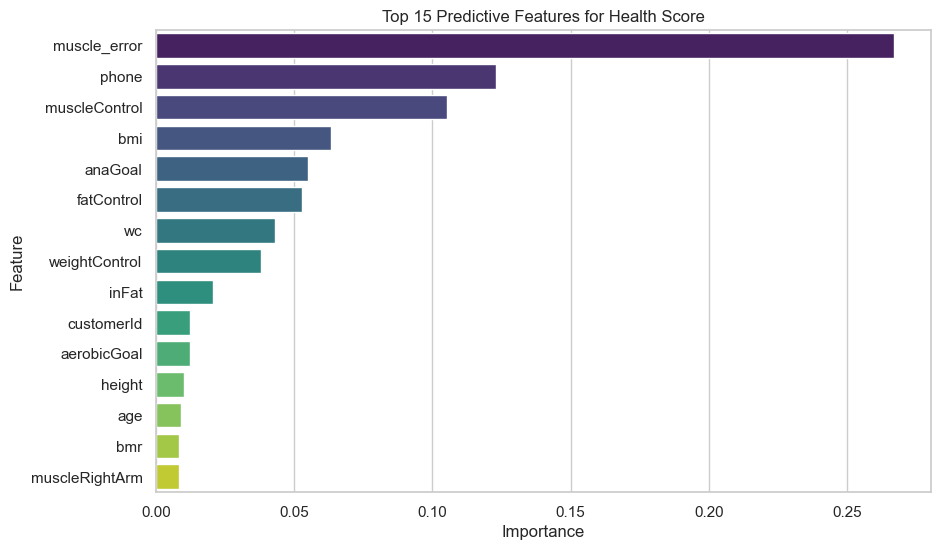


Top 10 Most Influential Variables:
          Feature  Importance
91   muscle_error    0.266912
42          phone    0.123129
33  muscleControl    0.105231
6             bmi    0.063438
2         anaGoal    0.055085
14     fatControl    0.052740
68             wc    0.043110
70  weightControl    0.038168
29          inFat    0.020585
74     customerId    0.012466


In [17]:
# Initializing the Random Forest Regressor (Inital Baseline Model)
# Using a limited depth and 100 trees to prevent excessive overfitting on the small dataset
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Training the model
model.fit(X_train, y_train)

# Evaluating on the Test Set
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Baseline Model Performance (Test Set):")
print(f"Mean Absolute Error: {mae:.2f} points")
print(f"R-squared Score: {r2:.2f}")

# Extracting and visualizing the top 15 most important features
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Predictive Features for Health Score')
plt.show()

# Displaying the top 10 features as a list
print("\nTop 10 Most Influential Variables:")
print(feature_importance_df.head(10))

New Model Performance (Test Set):
Mean Absolute Error: 11.90 points
R-squared Score: -6.29


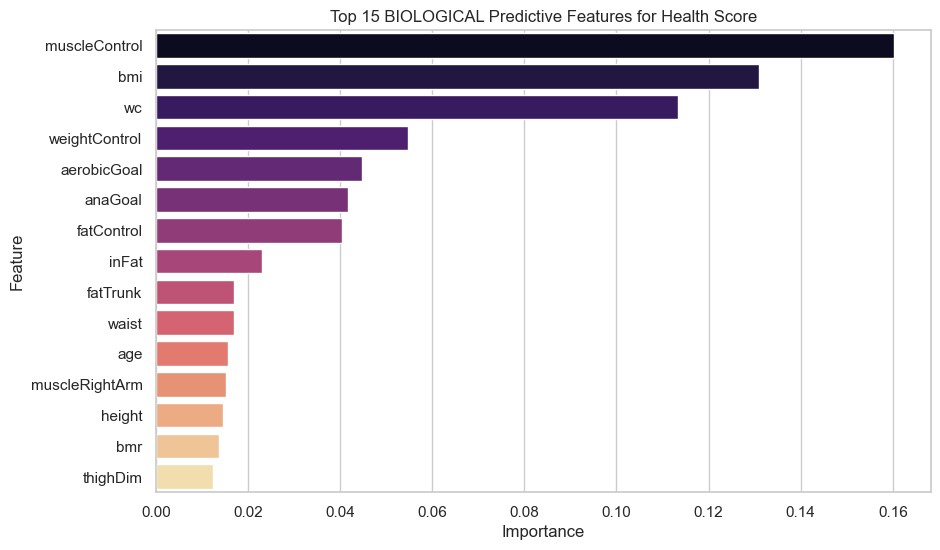


Top 10 Health Drivers:
          Feature  Importance
33  muscleControl    0.160214
6             bmi    0.130875
67             wc    0.113280
69  weightControl    0.054826
1     aerobicGoal    0.044835
2         anaGoal    0.041826
14     fatControl    0.040482
29          inFat    0.023159
19       fatTrunk    0.016982
65          waist    0.016914


In [18]:
# Identifying columns to remove definitively
# Removing identifiers (phone, customerId) and audit calculations (errors)
cols_to_remove = ['phone', 'customerId', 'muscle_error', 'fat_error', 'calc_total_muscle', 'calc_total_fat']

# Dropping from Training and Testing sets
X_train_clean = X_train.drop(columns=[c for c in cols_to_remove if c in X_train.columns])
X_test_clean = X_test.drop(columns=[c for c in cols_to_remove if c in X_test.columns])

# Re-training the Random Forest on biological data only
model_v2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_v2.fit(X_train_clean, y_train)

# Evaluating the new performance
y_pred_v2 = model_v2.predict(X_test_clean)
mae_v2 = mean_absolute_error(y_test, y_pred_v2)
r2_v2 = r2_score(y_test, y_pred_v2)

print(f"New Model Performance (Test Set):")
print(f"Mean Absolute Error: {mae_v2:.2f} points")
print(f"R-squared Score: {r2_v2:.2f}")

# Extracting new Feature Importance
importances_v2 = model_v2.feature_importances_
feature_importance_v2 = pd.DataFrame({
    'Feature': X_train_clean.columns,
    'Importance': importances_v2
}).sort_values(by='Importance', ascending=False)

# Visualizing the new, biological drivers
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_v2.head(15), hue='Feature', palette='magma', legend=False)
plt.title('Top 15 BIOLOGICAL Predictive Features for Health Score')
plt.show()

print("\nTop 10 Health Drivers:")
print(feature_importance_v2.head(10))

Simplified Model (Top 10 Features) Performance:
Mean Absolute Error: 14.98 points
R-squared Score: -10.26

Sample Comparison (Actual vs Predicted):
   Actual Score  Predicted Score
0            98             76.4
1            98             84.1
2            98             88.2
3            80             75.4
4            98             82.6
5            98             92.6
6            98             75.9
7            98             85.6
8            98             76.3
9            98             86.0


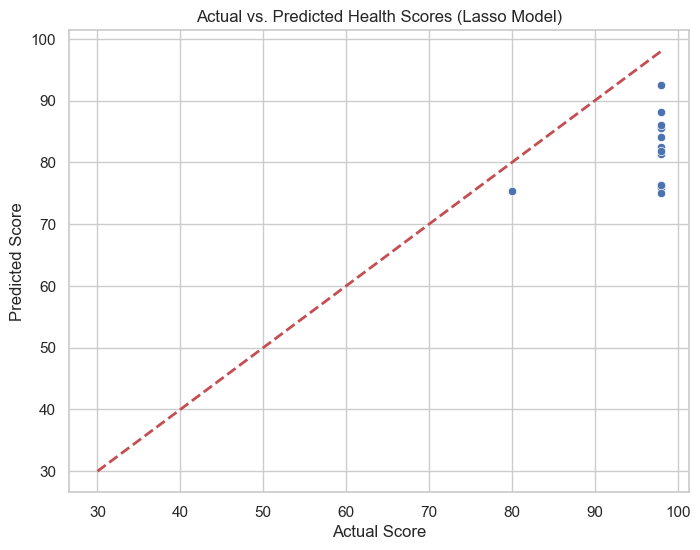

In [19]:
# Selecting only the top biological features identified in the previous step
top_features = feature_importance_v2.head(10)['Feature'].tolist()

X_train_simple = X_train_clean[top_features]
X_test_simple = X_test_clean[top_features]

# Initializing and training a Lasso model with Cross-Validation
# Lasso is better than Random Forest for very small datasets like ours
lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_simple, y_train)

# Evaluating the simplified model
y_pred_lasso = lasso_model.predict(X_test_simple)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Simplified Model (Top 10 Features) Performance:")
print(f"Mean Absolute Error: {mae_lasso:.2f} points")
print(f"R-squared Score: {r2_lasso:.2f}")

# Comparing Predicted vs Actual
comparison_df = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred_lasso
}).round(1)

print("\nSample Comparison (Actual vs Predicted):")
print(comparison_df.head(10))

# Visualizing the Error
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs. Predicted Health Scores (Lasso Model)')
plt.show()

Gradient Boosting Performance
CV Mean Absolute Error: 4.49 points
CV R-squared: -0.11


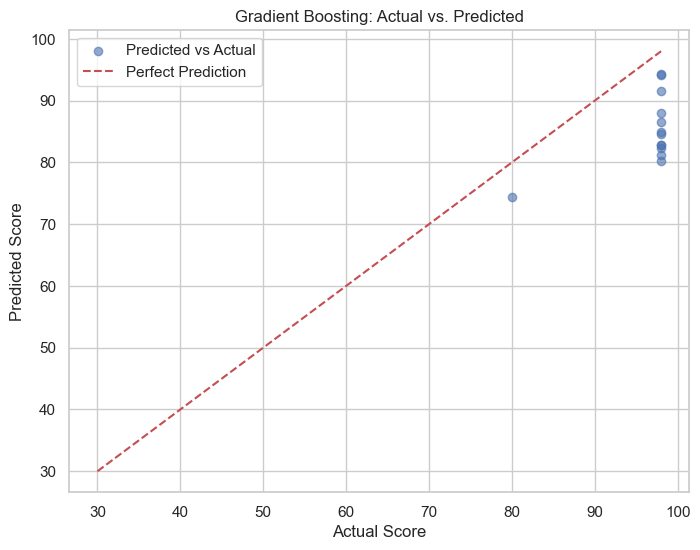

In [20]:
# Going back to using the Cleaned Features (non-cheating biological ones)
# Gradient Boosting handles many features and noise better than Lasso
X_final = X_train_clean 
y_final = y_train

# Initializing the Gradient Boosting model
# Using a low learning rate and small max_iter because the dataset is small
gb_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.05,
    max_depth=3, 
    random_state=42
)

# Performing 5-Fold Cross-Validation (Grouping by name)
# The most "scientific" way to report accuracy 
cv_results = cross_validate(
    gb_model, X_numeric.drop(columns=[target] + leakage_cols + ['id', 'original_url', 'date_created', 'date_modified'], errors='ignore'), y,
    groups=df[group_col],
    cv=gss,
    scoring=('neg_mean_absolute_error', 'r2')
)

# Final Training on the training set to see specific results
gb_model.fit(X_train_clean, y_train)
y_pred_gb = gb_model.predict(X_test_clean)

print("Gradient Boosting Performance")
print(f"CV Mean Absolute Error: {-cv_results['test_neg_mean_absolute_error'].mean():.2f} points")
print(f"CV R-squared: {cv_results['test_r2'].mean():.2f}")

# Visual Check
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.6, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', label='Perfect Prediction')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Gradient Boosting: Actual vs. Predicted')
plt.legend()
plt.show()

In [21]:
# Defining the biological feature set from the full numeric data
# Removing the "cheating" columns and identifiers from the start
cols_to_exclude = ['phone', 'customerId', 'muscle_error', 'fat_error', 
                   'calc_total_muscle', 'calc_total_fat', 'bodyAge', 'age_gap', 'score']
X_biological_full = X_numeric.drop(columns=[c for c in cols_to_exclude if c in X_numeric.columns])

# Creating the Binary Target for the full dataset
    # 1 = Optimal (91-100)
    # 0 = Needs Attention (<= 90)
y_class = (y > 90).astype(int)

# Performing the Scientific Group Split on the full data
gss_class = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss_class.split(X_biological_full, y_class, groups=df[group_col]))

X_train_c, X_test_c = X_biological_full.iloc[train_idx], X_biological_full.iloc[test_idx]
y_train_c, y_test_c = y_class.iloc[train_idx], y_class.iloc[test_idx]

# Initializing and Training the Classifier
# Using 'class_weight=balanced' because: 'Optimal' > 'Needs Attention'
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_c, y_train_c)

# Evaluating the results
y_pred_c = clf.predict(X_test_c)

print("Health Category Classification Report")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.2%}")
print("\nConfusion Matrix (Rows: Actual, Cols: Predicted):")
print(confusion_matrix(y_test_c, y_pred_c))
print("\nDetailed Metrics:")
print(classification_report(y_test_c, y_pred_c, target_names=['Needs Attention', 'Optimal']))

Health Category Classification Report
Accuracy: 23.08%

Confusion Matrix (Rows: Actual, Cols: Predicted):
[[ 1  0]
 [10  2]]

Detailed Metrics:
                 precision    recall  f1-score   support

Needs Attention       0.09      1.00      0.17         1
        Optimal       1.00      0.17      0.29        12

       accuracy                           0.23        13
      macro avg       0.55      0.58      0.23        13
   weighted avg       0.93      0.23      0.28        13



In [22]:
# If df_final is missing, load it from the previous CSV checkpoint we created
try:
    # Attempt to save the existing variable
    df_final.to_csv('data/Anovator_Biological_Master.csv', index=False)
    print("Variable 'df_final' found and saved to Master file.")
except NameError:
    # If the variable is gone, reload it from the last saved file
    print("Variable 'df_final' not found in memory. Reloading from previous save...")
    df_final = pd.read_csv('data/Anovator_Final_Cleaned_Dataset.csv')
    df_final.to_csv('data/Anovator_Biological_Master.csv', index=False)
    print("Master biological file recovered and saved.")

print("Total records ready for next notebook: ", len(df_final))

Variable 'df_final' found and saved to Master file.
Total records ready for next notebook:  158
